In [41]:
import numpy as numpy
import pandas as pd

importing data from out side to work space

In [42]:
data=pd.read_csv(r"C:\Users\ASUS\Downloads\archive (8)\Mall_Customers.csv")

In [43]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


display top 5 rows of data set

In [44]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


checking null values

In [45]:
data.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

find the shape of our data set

In [46]:
data.shape

(200, 5)

In [47]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


we dont nee customer so we are going to drop it

In [48]:
data=data.drop("CustomerID",axis=1)

In [49]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


we need to apply label encoding to gender because k-means algorithm will work efficienty with numerical data

In [50]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["Gender"]=le.fit_transform(data["Gender"])

In [51]:
data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


now applying k-means clustering algorithm to the modek

In [52]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit_transform(data)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([[ 51.73622741,  85.15598593,  33.78484143],
       [ 68.13808419,  74.72049047,  20.07809244],
       [ 58.23222532, 104.03437747,  64.31741441],
       [ 64.15134676,  73.44837568,  16.58531438],
       [ 45.18323056,  81.79021641,  31.76230599],
       [ 63.17008633,  72.64048114,  15.44995872],
       [ 52.0572743 , 101.84280325,  64.31719229],
       [ 75.14217793,  72.94137631,  28.29666455],
       [ 55.71203438, 107.88162206,  76.64361736],
       [ 56.73289256,  70.1716049 ,  12.27138699],
       [ 51.35683327, 101.37664852,  69.22644888],
       [ 76.17546681,  72.50605013,  33.69126333],
       [ 46.80269293,  97.35379526,  63.26193684],
       [ 61.1424181 ,  69.3531471 ,  13.21962054],
       [ 46.36435437,  95.54467982,  57.51236957],
       [ 63.20403571,  69.60502146,  14.96428401],
       [ 40.02368413,  80.92848688,  35.90326004],
       [ 55.19094539,  70.22563279,  10.97470189],
       [ 38.18619664,  84.89595059,  47.94000502],
       [ 73.24973941,  68.38685

In [53]:
K =range(2,11)
wcss=[]
for i in K:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(data)
    wcss.append(kmeans.inertia_)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

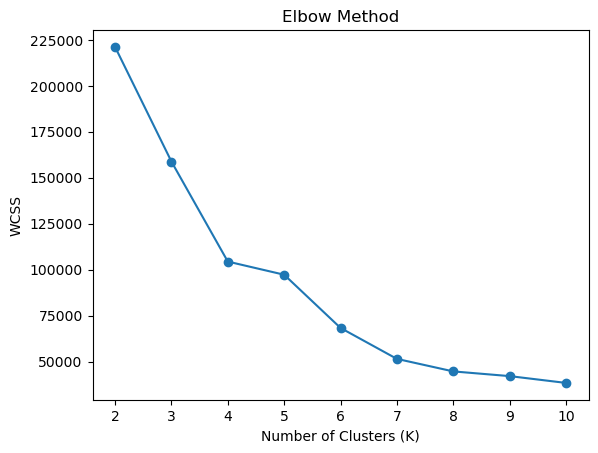

In [54]:
import matplotlib.pyplot as plt
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

Now we need to calculate sillhoute score to my modell

In [55]:
from sklearn.metrics import silhouette_score

In [56]:
silhoutee=[]
k=range(2,11)
for i in K:
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(data)
    score=silhouette_score(data,labels)
    silhoutee.append(score)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

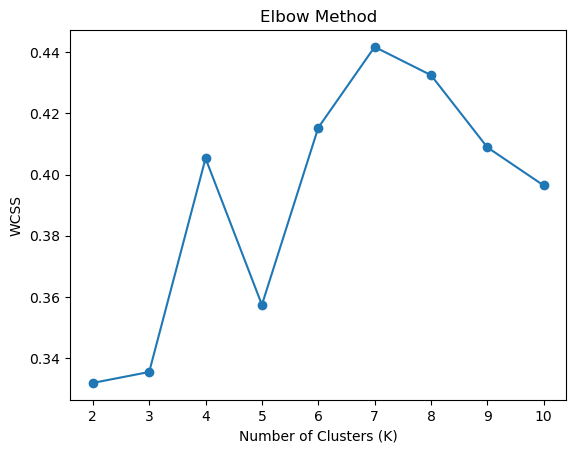

In [57]:
import matplotlib.pyplot as plt
plt.plot(range(2, 11), silhoutee, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [58]:
Y = labels
X=data

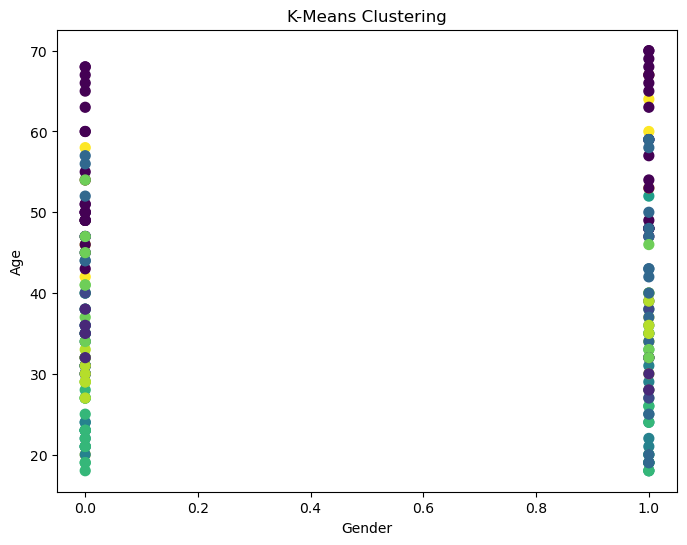

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(data.iloc[:,0], data.iloc[:,1],
            c=labels,
            cmap='viridis',
            s=50)

plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.title("K-Means Clustering")

plt.show()

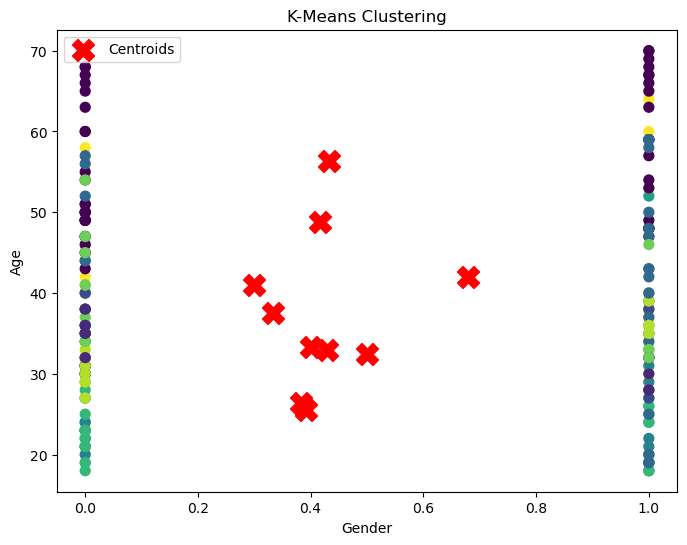

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(data.iloc[:,0], data.iloc[:,1],
            c=labels,
            cmap='viridis',
            s=50)

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='red',
            marker='X',
            s=250,
            label='Centroids')

plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])
plt.title("K-Means Clustering")
plt.legend()

plt.show()

In [61]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=7,random_state=42)
kmeans.fit_transform(data)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([[ 54.77759314, 108.13823353,  41.66651292, ...,  79.93946074,
         33.28846498,  44.32892979],
       [ 61.2108367 , 100.46829127,  12.43113355, ...,  66.43092189,
         65.93891175,  53.90929337],
       [ 68.0063044 , 123.12429426,  73.5019257 , ..., 101.10949452,
         29.84557362,  59.81375758],
       ...,
       [ 80.15776025,  12.17810012, 100.01201251, ...,  46.49938046,
        114.38624397,  73.26341311],
       [ 92.28238866,  64.41732559, 126.34876866, ...,  86.16230256,
        111.93193586,  85.26214262],
       [ 93.60649347,  22.95381343, 110.87659824, ...,  56.68833551,
        128.49737914,  86.72795528]], shape=(200, 7))

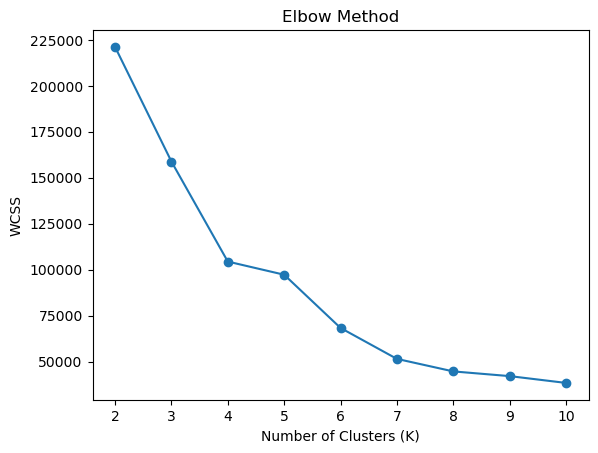

In [62]:
import matplotlib.pyplot as plt
plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


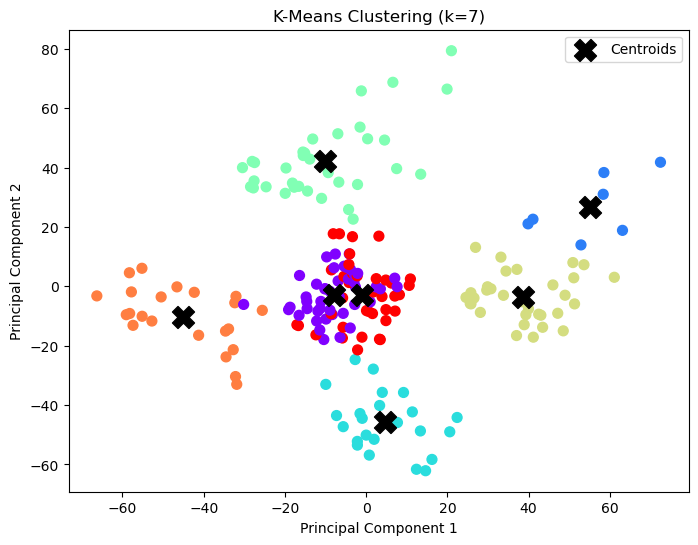

In [63]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Train K-Means
kmeans = KMeans(n_clusters=7, random_state=42)
labels = kmeans.fit_predict(data)

# Reduce data to 2 dimensions
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Transform cluster centers to PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(data_pca[:,0],
            data_pca[:,1],
            c=labels,
            cmap='rainbow',
            s=50)

plt.scatter(centers_pca[:,0],
            centers_pca[:,1],
            color='black',
            marker='X',
            s=250,
            label='Centroids')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (k=7)")
plt.legend()
plt.show()